# 05 Conditions, Events, and Windows

Event analysis converts sample-wise signals into meaningful moments, intervals, and event-centered windows.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from IPython.display import display

from tal import AnalysisObject
from tal.core.event_ops import AroundOptions, Condition, AtBoundariesOptions, WhenOptions

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Setup: a scalar signal with threshold crossings

Keep the signal simple enough that expected crossings can be checked by eye.


In [2]:
t = np.linspace(0.0, 6.0, 61)
values = np.sin(t) + 0.15 * np.cos(3.0 * t)
ds = xr.Dataset(
    data_vars={'value': ('sample', values)},
    coords={
        'sample': np.arange(values.size),
        'time': ('sample', t),
    },
)
ao = AnalysisObject.from_data(ds, sequence_dim='sample', core_dims=(), param_coord='time', validate=True)

threshold = -0.5
cond = Condition.compare(Condition.var('value'), 'gt', threshold)


## Define a condition and evaluate event products

`Condition` is a small symbolic expression. It is evaluated against an AO by the `events` accessor.


In [3]:
boundaries_all = ao.events.at_boundaries(cond, opts=AtBoundariesOptions(edges='all', mode='all'))
when_mask = ao.events.when(cond, opts=WhenOptions(layout='mask', inside=True))
when_stream = ao.events.when(cond, opts=WhenOptions(layout='stream', max_segments=16))
around_exit = ao.events.around(cond, opts=AroundOptions(edge='exit', pre=0.3, post=0.3, dt=0.05))

display_result(
    'Event product summary',
    pd.DataFrame(
        [
            {'result': 'at_boundaries', 'type': type(boundaries_all).__name__, 'dims': dict(boundaries_all.as_dataset().sizes)},
            {'result': 'when(layout="mask")', 'type': type(when_mask).__name__, 'dims': dict(when_mask.as_dataset().sizes)},
            {'result': 'when(layout="stream")', 'type': type(when_stream).__name__, 'dims': dict(when_stream.as_dataset().sizes)},
            {'result': 'around(edge="exit")', 'type': type(around_exit).__name__, 'dims': dict(around_exit.as_dataset().sizes)},
        ]
    ),
)


#### Event product summary

,result,type,dims
0,at_boundaries,AnalysisObject,{'event': 3}
1,"when(layout=""mask"")",AnalysisObject,{'sample': 61}
2,"when(layout=""stream"")",AnalysisObject,{'stream_sample': 976}
3,"around(edge=""exit"")",AnalysisObject,"{'event': 2, 'tau': 13}"


,result,type,dims
0,at_boundaries,AnalysisObject,{'event': 3}
1,"when(layout=""mask"")",AnalysisObject,{'sample': 61}
2,"when(layout=""stream"")",AnalysisObject,{'stream_sample': 976}
3,"around(edge=""exit"")",AnalysisObject,"{'event': 2, 'tau': 13}"


What to notice

`at_boundaries`, `when`, and `around` answer different questions about the same condition.


## `where` vs `when` layouts

`ao.where(mask)` is ordinary mask application: you provide an already-evaluated boolean mask and TAL keeps the original AO topology. `ao.events.when(...)` evaluates the condition inside the event API. With `layout="mask"`, it behaves like a topology-preserving mask. With `layout="stream"`, TAL extracts selected samples into a compact event stream and adds segment metadata. Stream time is local to each segment, so plotting it on the original time axis requires reconstructing absolute time per segment.

## Plot the condition

Use TAL to evaluate the condition, then compare two layouts. `ao.where(mask)` and `events.when(layout="mask")` keep the original sample grid, so false regions become gaps. `events.when(layout="stream")` compacts selected samples, which is useful for tables and streams but can visually connect disconnected intervals.

#### Numeric layout comparison

,layout,sequence_dim,allocated_rows,selected_rows,segment_count,time_meaning
0,source AO,sample,61,40,,absolute param coordinate
1,ao.where(mask),sample,61,40,,absolute param coordinate
2,"events.when(layout=""mask"")",sample,61,40,,absolute param coordinate
3,"events.when(layout=""stream"")",stream_sample,976,40,2,segment-relative; add segment_start_time for a...


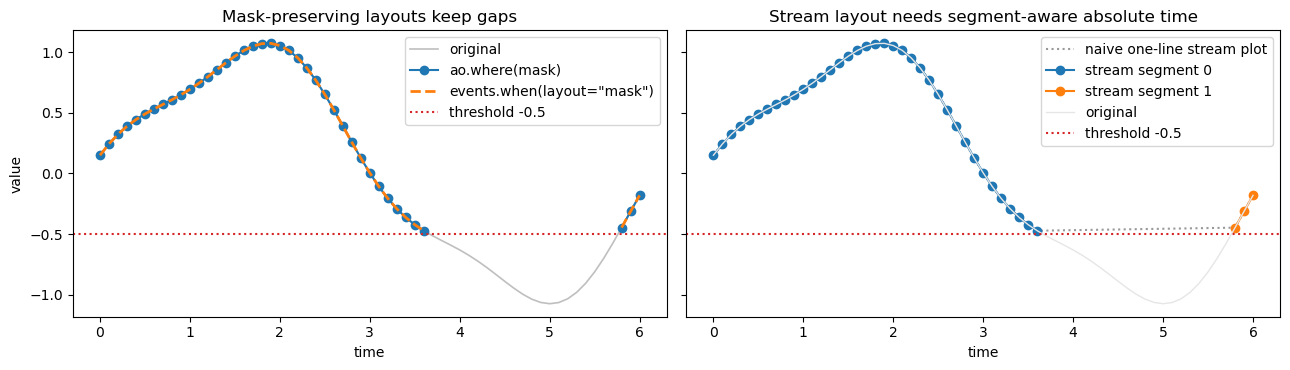

In [4]:
mask = ao.events.mask(cond)
where_selected = ao.where(mask)
when_mask_selected = ao.events.when(cond, opts=WhenOptions(layout='mask', inside=True))
when_stream_selected = ao.events.when(cond, opts=WhenOptions(layout='stream', max_segments=16))

source_ds = ao.as_dataset()
where_ds = where_selected.as_dataset()
when_mask_ds = when_mask_selected.as_dataset()
stream_ds = when_stream_selected.as_dataset()

stream_size = int(stream_ds['stream_size'])
stream_valid = stream_ds.isel(stream_sample=slice(0, stream_size))
segment_ids = [
    int(value)
    for value in np.unique(stream_valid['stream_segment_index'].to_numpy())
    if int(value) >= 0
]

display_result(
    'Numeric layout comparison',
    pd.DataFrame(
        [
            {
                'layout': 'source AO',
                'sequence_dim': 'sample',
                'allocated_rows': source_ds.sizes['sample'],
                'selected_rows': int(mask.sum()),
                'segment_count': '',
                'time_meaning': 'absolute param coordinate',
            },
            {
                'layout': 'ao.where(mask)',
                'sequence_dim': 'sample',
                'allocated_rows': where_ds.sizes['sample'],
                'selected_rows': int(np.isfinite(where_ds['value']).sum()),
                'segment_count': '',
                'time_meaning': 'absolute param coordinate',
            },
            {
                'layout': 'events.when(layout="mask")',
                'sequence_dim': 'sample',
                'allocated_rows': when_mask_ds.sizes['sample'],
                'selected_rows': int(np.isfinite(when_mask_ds['value']).sum()),
                'segment_count': '',
                'time_meaning': 'absolute param coordinate',
            },
            {
                'layout': 'events.when(layout="stream")',
                'sequence_dim': 'stream_sample',
                'allocated_rows': stream_ds.sizes['stream_sample'],
                'selected_rows': stream_size,
                'segment_count': len(segment_ids),
                'time_meaning': 'segment-relative; add segment_start_time for absolute plots',
            },
        ]
    ),
)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)

axes[0].plot(source_ds['time'], source_ds['value'], color='0.75', linewidth=1.2, label='original')
axes[0].plot(where_ds['time'], where_ds['value'], 'o-', label='ao.where(mask)')
axes[0].plot(
    when_mask_ds['time'],
    when_mask_ds['value'],
    linestyle='--',
    linewidth=2.0,
    label='events.when(layout="mask")',
)
axes[0].axhline(threshold, color='tab:red', linestyle=':', label=f'threshold {threshold:g}')
axes[0].set(
    title='Mask-preserving layouts keep gaps',
    xlabel='time',
    ylabel='value',
)
axes[0].legend(loc='best')

absolute_stream_time = stream_valid['segment_start_time'] + stream_valid['time']
axes[1].plot(
    absolute_stream_time,
    stream_valid['value'],
    ':',
    color='0.6',
    label='naive one-line stream plot',
)
for segment_id in segment_ids:
    segment = stream_valid.where(stream_valid['stream_segment_index'] == segment_id, drop=True)
    segment_mask = np.isfinite(segment['value'].to_numpy())
    segment_time = (segment['segment_start_time'] + segment['time']).to_numpy()
    axes[1].plot(
        segment_time[segment_mask],
        segment['value'].to_numpy()[segment_mask],
        'o-',
        label=f'stream segment {segment_id}',
    )
axes[1].plot(source_ds['time'], source_ds['value'], color='0.9', linewidth=1.0, label='original')
axes[1].axhline(threshold, color='tab:red', linestyle=':', label=f'threshold {threshold:g}')
axes[1].set(
    title='Stream layout needs segment-aware absolute time',
    xlabel='time',
)
axes[1].legend(loc='best')
fig.tight_layout()


Around-event windows answer a different question: what did the signal look like near each entry into the condition?

[Text(0.5, 1.0, 'Around-event windows align entries at t=0'),
 Text(0.5, 0, 'tau'),
 Text(0, 0.5, 'value')]

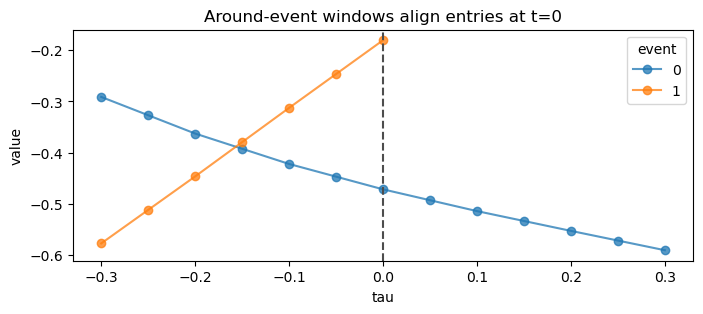

In [5]:
window_ds = around_exit.as_dataset()
var_name = next(iter(window_ds.data_vars))
window_dim = 'window_time' if 'window_time' in window_ds.coords else window_ds[var_name].dims[-1]
event_dim = next((dim for dim in window_ds[var_name].dims if dim != window_dim), None)

fig, ax = plt.subplots(figsize=(8, 3))
if event_dim is None:
    ax.plot(window_ds[window_dim], window_ds[var_name], marker='o')
else:
    for event_label in window_ds[event_dim].to_numpy():
        ax.plot(
            window_ds[window_dim],
            window_ds[var_name].sel({event_dim: event_label}),
            marker='o',
            alpha=0.75,
            label=str(event_label),
        )
    ax.legend(title=event_dim, loc='best')
ax.axvline(0.0, color='0.3', linestyle='--')
ax.set(title='Around-event windows align entries at t=0', xlabel=window_dim, ylabel=var_name)


## Events vs intervals

Events are boundary moments. Intervals are contiguous regions where a condition holds.


In [6]:
cold = Condition.compare(Condition.var('value'), 'lt', -0.6)
combined = cond | cold
events = ao.events.events(combined)
intervals = ao.events.intervals(combined)

events, intervals


(<xarray.Dataset> Size: 165B
 Dimensions:              (event: 5)
 Coordinates:
   * event                (event) int64 40B 0 1 2 3 4
 Data variables:
     time                 (event) float64 40B 3.6 4.0 5.6 5.8 6.0
     edge_code            (event) int8 5B 2 1 2 1 2
     sample_index_before  (event) int64 40B 36 39 56 57 60
     sample_index_after   (event) int64 40B 37 40 57 58 -1,
 <xarray.Dataset> Size: 100B
 Dimensions:        (segment: 2, edge: 2)
 Coordinates:
   * segment        (segment) int64 16B 0 1
   * edge           (edge) object 16B 'start' 'end'
 Data variables:
     time           (segment, edge) float64 32B 4.0 5.6 5.8 6.0
     sample_index   (segment, edge) int64 32B 40 56 58 60
     is_trigger     (segment) bool 2B False False
     valid_segment  (segment) bool 2B True True)

## Combining conditions

Conditions can be composed with `|`, `&`, and `~` before evaluation.


## Choosing an event API

| Need | API |
|---|---|
| boolean mask | `ao.events.mask` |
| boundary rows | `ao.events.events` |
| contiguous spans | `ao.events.intervals` |
| samples at crossings | `ao.events.at_boundaries` |
| selected samples | `ao.events.when` |
| event-centered windows | `ao.events.around` |

**Exercise:** change the threshold and compare `edge="exit"` with `edge="enter"` in `AroundOptions`.
